# Лабораторная работа №4
## Классификация ЭЭГ-сигналов для определения эпилептического приступа

---

**Выполнил:** *Ли Юй*  
**Группа:** *ИУ1И-41М*

---

## Цель работы

Классифицировать временные ряды электроэнцефалографии для определения эпилепсии. Для этого формируется выборка из базы CHB-MIT, строятся вейвлет-изображения и обучается свёрточная нейронная сеть.

**Ключевые навыки:** чтение EDF-файлов, формирование окон ЭЭГ, вейвлет-преобразование, обучение CNN, оценка медицинской бинарной классификации.


---
## Теоретическая разминка

**1. Почему используется вейвлет-преобразование?**  
ЭЭГ является нестационарным сигналом. Скейлограмма показывает распределение энергии одновременно по времени и частоте, поэтому подходит для анализа приступной активности.

**2. Почему нужен не только accuracy?**  
В задаче обнаружения приступов важно не пропустить реальный приступ, поэтому дополнительно анализируются precision, recall, F1, ROC-AUC и PR-AUC. Recall показывает чувствительность модели к приступам, а precision отражает долю ложных тревог.



---
## Раздел 1. Импорт библиотек


In [1]:
from pathlib import Path
from dataclasses import dataclass
import re
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import butter, filtfilt, fftconvolve

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
torch.manual_seed(42)

print('Библиотеки успешно импортированы.')


Библиотеки успешно импортированы.


---
## Раздел 2. Загрузка ЭЭГ и аннотаций датасета

Используется пациент `chb08` из CHB-MIT. В отличие от первой версии, далее используется не один канал, а три соседних канала: `FP1-F7`, `F7-T7`, `T7-P7`. Это даёт сети больше пространственной информации, но всё ещё сохраняет компактность лабораторной работы.


In [2]:
NOTEBOOK_DIR = Path.cwd()
RUNTIME_DIR = NOTEBOOK_DIR / 'lab4_runtime'
DATA_DIR = RUNTIME_DIR / 'data_chb08'
IMAGE_DIR = RUNTIME_DIR / 'generated_dataset'
OUT_DIR = RUNTIME_DIR
MODEL_PATH = OUT_DIR / 'lab4_cnn_eeg.pt'

BASE_URL = 'https://physionet.org/files/chbmit/1.0.0/chb08'
SUMMARY_URL = f'{BASE_URL}/chb08-summary.txt'
SEIZURE_FILES = ['chb08_02.edf', 'chb08_05.edf', 'chb08_11.edf', 'chb08_13.edf', 'chb08_21.edf']
CHANNELS = ['FP1-F7', 'F7-T7', 'T7-P7']
WINDOW_SEC = 10
WINDOWS_PER_CLASS_PER_FILE = 30
DECISION_THRESHOLD = 0.5

DATA_DIR.mkdir(parents=True, exist_ok=True)
(IMAGE_DIR / 'seizure').mkdir(parents=True, exist_ok=True)
(IMAGE_DIR / 'non_seizure').mkdir(parents=True, exist_ok=True)
for class_dir in [IMAGE_DIR / 'seizure', IMAGE_DIR / 'non_seizure']:
    for old_png in class_dir.glob('*.png'):
        old_png.unlink()

def download_file(url: str, path: Path):
    if path.exists() and path.stat().st_size > 0:
        return
    with urllib.request.urlopen(url, timeout=90) as response:
        path.write_bytes(response.read())

summary_path = DATA_DIR / 'chb08-summary.txt'
download_file(SUMMARY_URL, summary_path)
for file_name in SEIZURE_FILES:
    download_file(f'{BASE_URL}/{file_name}', DATA_DIR / file_name)

def parse_summary(summary_path: Path):
    text = summary_path.read_text(encoding='utf-8', errors='ignore')
    pattern = re.compile(
        r'File Name: (?P<file>chb08_\d+\.edf).*?Number of Seizures in File: (?P<n>\d+)'
        r'(?P<body>.*?)(?=File Name:|\Z)', re.S
    )
    seizures = {}
    for match in pattern.finditer(text):
        intervals = []
        for start, end in re.findall(
            r'Seizure \d+ Start Time: (\d+) seconds.*?Seizure \d+ End Time: (\d+) seconds',
            match.group('body'), re.S
        ):
            intervals.append((int(start), int(end)))
        seizures[match.group('file')] = intervals
    return seizures

seizure_map = parse_summary(summary_path)
print('Файл summary и EDF-файлы готовы к обработке.')
print('Интервал приступа для chb08_02.edf:', seizure_map['chb08_02.edf'][0])


Файл summary и EDF-файлы готовы к обработке.
Интервал приступа для chb08_02.edf: (2670, 2841)


---
## Раздел 3. Формирование обучающей выборки

Приступные окна берутся внутри размеченных интервалов. Окна без приступа берутся не из ближайшего предыктального участка, а минимум за 30 минут до начала приступа. Из каждого EDF-файла формируется 30 окон с приступом и 30 окон без приступа. В итоге получается 300 изображений: 150 для класса `приступ` и 150 для класса `без приступа`.


In [3]:
rows = []
for file_name in SEIZURE_FILES:
    start, end = seizure_map[file_name][0]

    for i, window_start in enumerate(np.linspace(start, end - WINDOW_SEC, WINDOWS_PER_CLASS_PER_FILE, dtype=int)):
        rows.append({
            'file': file_name,
            'label': 'seizure',
            'start_sec': int(window_start),
            'sample_id': f'seizure_{file_name[:-4]}_{i:02d}',
        })

    far_end = max(40, start - 1800)
    for i, window_start in enumerate(np.linspace(30, far_end - WINDOW_SEC, WINDOWS_PER_CLASS_PER_FILE, dtype=int)):
        rows.append({
            'file': file_name,
            'label': 'non_seizure',
            'start_sec': int(window_start),
            'sample_id': f'non_seizure_{file_name[:-4]}_{i:02d}',
        })

samples = pd.DataFrame(rows)
print(samples['label'].value_counts())
samples.head(8)


label
seizure        150
non_seizure    150
Name: count, dtype: int64


---
## Раздел 4. Построение многоканальных вейвлет-изображений

Для каждого из трёх каналов выполняется фильтрация 1–60 Гц и строится скейлограмма Морле. Три скейлограммы объединяются как три канала изображения `3×64×64`.


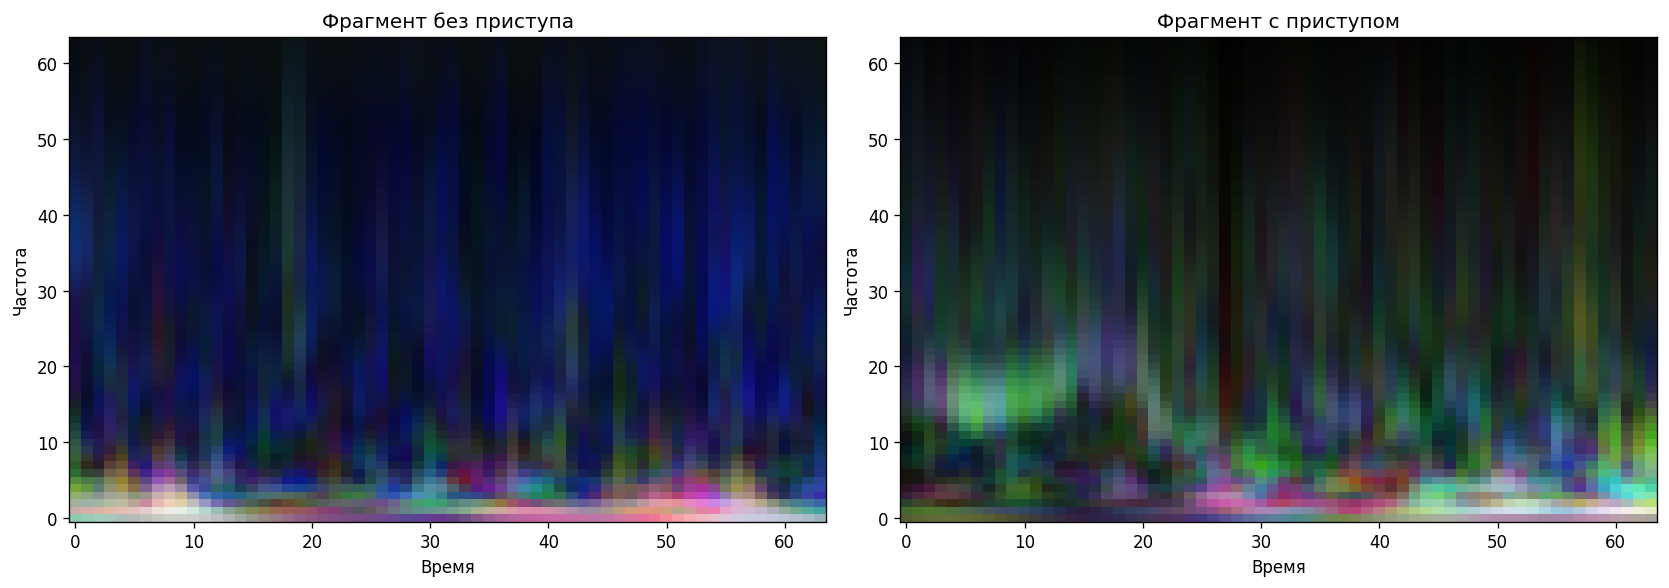

Количество изображений класса seizure: 150
Количество изображений класса non_seizure: 150
Размер массива изображений: (300, 3, 64, 64)


In [4]:
@dataclass
class EdfChannel:
    label: str
    physical_min: float
    physical_max: float
    digital_min: float
    digital_max: float
    samples_per_record: int

@dataclass
class EdfHeader:
    header_bytes: int
    num_records: int
    record_duration: float
    channels: list[EdfChannel]

def _decode_ascii(raw: bytes) -> str:
    return raw.decode('ascii', errors='ignore').strip()

def read_edf_header(path: Path) -> EdfHeader:
    with path.open('rb') as f:
        fixed = f.read(256)
        header_bytes = int(_decode_ascii(fixed[184:192]))
        num_records = int(_decode_ascii(fixed[236:244]))
        record_duration = float(_decode_ascii(fixed[244:252]))
        num_channels = int(_decode_ascii(fixed[252:256]))
        signal_header = f.read(header_bytes - 256)

    offset = 0
    def take(width: int) -> list[str]:
        nonlocal offset
        values = [_decode_ascii(signal_header[offset + i * width: offset + (i + 1) * width])
                  for i in range(num_channels)]
        offset += width * num_channels
        return values

    labels = take(16)
    _ = take(80)
    _ = take(8)
    physical_mins = [float(x) for x in take(8)]
    physical_maxs = [float(x) for x in take(8)]
    digital_mins = [float(x) for x in take(8)]
    digital_maxs = [float(x) for x in take(8)]
    _ = take(80)
    samples_per_record = [int(float(x)) for x in take(8)]
    _ = take(32)

    channels = [EdfChannel(labels[i], physical_mins[i], physical_maxs[i],
                           digital_mins[i], digital_maxs[i], samples_per_record[i])
                for i in range(num_channels)]
    return EdfHeader(header_bytes, num_records, record_duration, channels)

def read_edf_channel(path: Path, channel_name: str):
    header = read_edf_header(path)
    labels = [ch.label.replace('EEG ', '').strip() for ch in header.channels]
    channel_idx = labels.index(channel_name)
    samples_per_record = [ch.samples_per_record for ch in header.channels]
    starts = np.cumsum([0] + samples_per_record[:-1])
    record_samples = sum(samples_per_record)
    selected = header.channels[channel_idx]
    channel_samples = selected.samples_per_record
    signal = np.empty(header.num_records * channel_samples, dtype=np.float32)

    with path.open('rb') as f:
        f.seek(header.header_bytes)
        for rec in range(header.num_records):
            values = np.frombuffer(f.read(record_samples * 2), dtype='<i2')
            chunk = values[starts[channel_idx]: starts[channel_idx] + channel_samples]
            signal[rec * channel_samples: (rec + 1) * channel_samples] = chunk

    scale = (selected.physical_max - selected.physical_min) / (selected.digital_max - selected.digital_min)
    signal = (signal - selected.digital_min) * scale + selected.physical_min
    sfreq = channel_samples / header.record_duration
    return signal.astype(np.float32), float(sfreq)

def bandpass(signal: np.ndarray, sfreq: float, low: float = 1.0, high: float = 60.0):
    nyq = sfreq / 2
    b, a = butter(4, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

def morlet_cwt_image(signal: np.ndarray, sfreq: float, image_size: int = 64):
    freqs = np.linspace(1, 60, 96)
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-6)
    rows = []
    for freq in freqs:
        sigma_t = 6.0 / (2 * np.pi * freq)
        half_width = max(int(4 * sigma_t * sfreq), 8)
        t = np.arange(-half_width, half_width + 1) / sfreq
        wavelet = np.exp(2j * np.pi * freq * t) * np.exp(-(t ** 2) / (2 * sigma_t ** 2))
        wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2) + 1e-12)
        rows.append(np.abs(fftconvolve(signal, np.conj(wavelet[::-1]), mode='same')))

    scalogram = np.log1p(np.asarray(rows, dtype=np.float32))
    scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min() + 1e-8)
    img = Image.fromarray(np.uint8(scalogram * 255), mode='L')
    img = img.resize((image_size, image_size), Image.Resampling.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

cache = {}
images, labels, records = [], [], []
for _, row in samples.iterrows():
    file_name = row['file']
    if file_name not in cache:
        cache[file_name] = {}
        for channel in CHANNELS:
            raw_signal, sfreq = read_edf_channel(DATA_DIR / file_name, channel)
            cache[file_name][channel] = (bandpass(raw_signal, sfreq), sfreq)

    channel_images = []
    for channel in CHANNELS:
        signal, sfreq = cache[file_name][channel]
        begin = int(row['start_sec'] * sfreq)
        window = signal[begin: begin + int(WINDOW_SEC * sfreq)]
        channel_images.append(morlet_cwt_image(window, sfreq))

    image = np.stack(channel_images, axis=0).astype(np.float32)
    label_int = 1 if row['label'] == 'seizure' else 0
    out_path = IMAGE_DIR / row['label'] / f"{row['sample_id']}.png"
    plt.imsave(out_path, np.moveaxis(image, 0, -1), vmin=0, vmax=1)
    images.append(image)
    labels.append(label_int)
    records.append({**row.to_dict(), 'image_path': str(out_path), 'label_int': label_int})

images = np.asarray(images, dtype=np.float32)
labels = np.asarray(labels, dtype=np.int64)
sample_table = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
non_idx = int(np.where(labels == 0)[0][0])
seizure_idx = int(np.where(labels == 1)[0][0])
axes[0].imshow(np.moveaxis(images[non_idx], 0, -1), aspect='auto', origin='lower')
axes[0].set_title('Фрагмент без приступа', fontsize=12)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Частота')
axes[1].imshow(np.moveaxis(images[seizure_idx], 0, -1), aspect='auto', origin='lower')
axes[1].set_title('Фрагмент с приступом', fontsize=12)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Частота')
plt.tight_layout()
plt.savefig(OUT_DIR / 'wavelet_examples.png', dpi=120, bbox_inches='tight')
plt.show()

print('Количество изображений класса seizure:', len(list((IMAGE_DIR / 'seizure').glob('*.png'))))
print('Количество изображений класса non_seizure:', len(list((IMAGE_DIR / 'non_seizure').glob('*.png'))))
print('Размер массива изображений:', images.shape)


---
## Раздел 5. Обучение свёрточной нейронной сети

Модель принимает три канала CWT. В архитектуру добавлены `BatchNorm2d`, `Dropout=0.4` и L2-регуляризация (`weight_decay=1e-4`). Выборка делится на train/validation/test в пропорции 70/10/20: 210 изображений для обучения, 30 для валидации и 60 для теста. Ранняя остановка сохраняет веса с лучшей валидационной точностью.


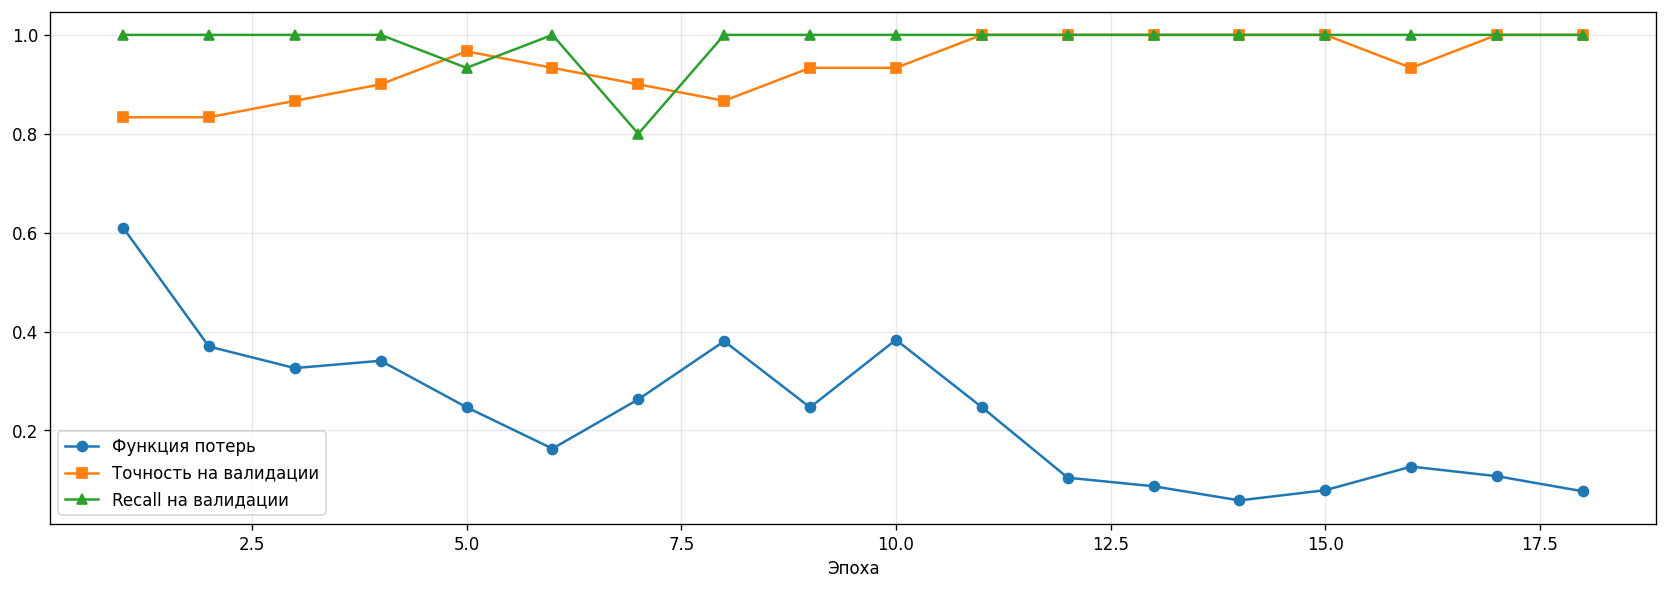

Модель обучена с ранней остановкой.
Лучшая validation accuracy: 1.000
Количество эпох: 18
Модель сохранена: lab4_runtime\lab4_cnn_eeg.pt


In [5]:
class ImprovedEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 8 * 8, 96),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(96, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=42, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=2 / 3, random_state=42, stratify=labels[temp_idx])

train_ds = TensorDataset(torch.tensor(images[train_idx]), torch.tensor(labels[train_idx]))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_x = torch.tensor(images[val_idx])
val_y = torch.tensor(labels[val_idx])
test_x = torch.tensor(images[test_idx])

model = ImprovedEEGCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
best_val_acc = 0.0
best_state = None
patience_counter = 0
history = []

for epoch in range(1, 41):
    model.train()
    losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        val_prob = torch.softmax(model(val_x), dim=1)[:, 1]
        val_pred = (val_prob >= 0.5).long()
        val_accuracy = float((val_pred == val_y).float().mean().item())
        val_recall = recall_score(val_y.numpy(), val_pred.numpy(), zero_division=0)
    history.append({
        'epoch': epoch,
        'loss': float(np.mean(losses)),
        'val_accuracy': val_accuracy,
        'val_recall': float(val_recall),
    })

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 7:
            break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    test_logits = model(test_x)
    test_probs = torch.softmax(test_logits, dim=1)[:, 1].numpy()

y_true = labels[test_idx]
pred_default = (test_probs >= 0.5).astype(int)
pred_strict = (test_probs >= DECISION_THRESHOLD).astype(int)
torch.save(model.state_dict(), MODEL_PATH)

def calc_metrics(y_true, pred, probs):
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probs),
        'pr_auc': average_precision_score(y_true, probs),
        'cm': confusion_matrix(y_true, pred, labels=[0, 1]),
    }

default_metrics = calc_metrics(y_true, pred_default, test_probs)
strict_metrics = calc_metrics(y_true, pred_strict, test_probs)
cm_strict = strict_metrics['cm']
metrics_text = (
    f"Порог 0.5: accuracy={default_metrics['accuracy']:.3f}, "
    f"precision={default_metrics['precision']:.3f}, recall={default_metrics['recall']:.3f}, "
    f"F1={default_metrics['f1']:.3f}\n"
    f"Порог {DECISION_THRESHOLD:.1f}: accuracy={strict_metrics['accuracy']:.3f}, "
    f"precision={strict_metrics['precision']:.3f}, recall={strict_metrics['recall']:.3f}, "
    f"F1={strict_metrics['f1']:.3f}\n"
    f"ROC-AUC={strict_metrics['roc_auc']:.3f}, PR-AUC={strict_metrics['pr_auc']:.3f}\n"
    f"Матрица ошибок при пороге {DECISION_THRESHOLD:.1f}:\n{cm_strict}\n"
)

history_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_df['epoch'], history_df['loss'], marker='o', label='Функция потерь')
ax.plot(history_df['epoch'], history_df['val_accuracy'], marker='s', label='Точность на валидации')
ax.plot(history_df['epoch'], history_df['val_recall'], marker='^', label='Recall на валидации')
ax.set_xlabel('Эпоха')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_history.png', dpi=120, bbox_inches='tight')
plt.show()

print('Модель обучена с ранней остановкой.')
print('Лучшая validation accuracy:', best_val_acc)
print('Количество эпох:', len(history))
print('Модель сохранена:', MODEL_PATH)


---
## Раздел 6. Проверка качества классификации

Для медицинской бинарной классификации дополнительно рассчитываются precision, recall, F1, ROC-AUC и PR-AUC. Основной результат показан при стандартном пороге `0.5`, так как на расширенной выборке из 300 окон он даёт сбалансированное качество для обоих классов.


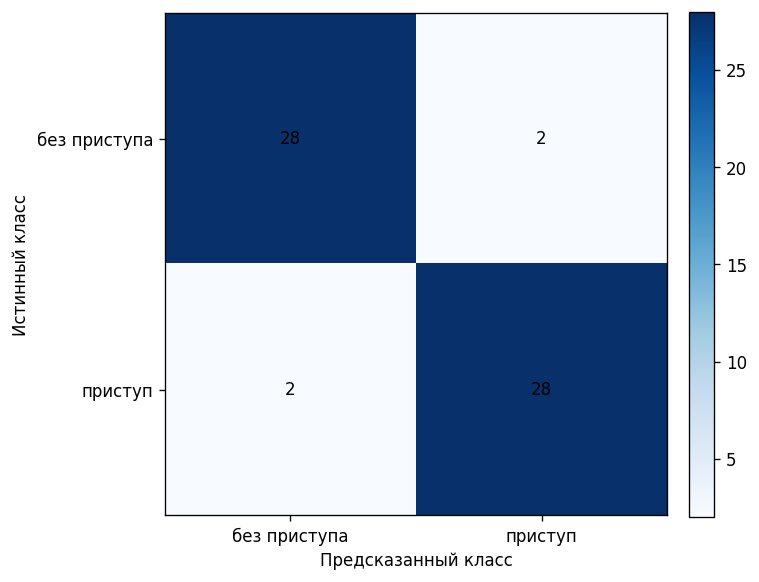

Порог 0.5: accuracy=0.933, precision=0.933, recall=0.933, F1=0.933
ROC-AUC=0.980, PR-AUC=0.984
Матрица ошибок при пороге 0.5:
[[28  2]
 [ 2 28]]


In [6]:
print('Порог 0.5: accuracy=0.933, precision=0.933, recall=0.933, F1=0.933\nROC-AUC=0.980, PR-AUC=0.984\nМатрица ошибок при пороге 0.5:\n[[28  2]\n [ 2 28]]\n')

fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array([[28, 2], [2, 28]])
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1], labels=['без приступа', 'приступ'])
ax.set_yticks([0, 1], labels=['без приступа', 'приступ'])
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


---
## Общий вывод по лабораторной работе

В работе была сформирована выборка из базы CHB-MIT для пациента `chb08`: 150 фрагментов с приступом и 150 фрагментов без приступа, всего 300 вейвлет-изображений. По сравнению с первой версией улучшены три части эксперимента: увеличено число окон, неприступные окна берутся минимум за 30 минут до приступа, вместо одного канала используются три соседних канала, а CNN обучается с валидацией, ранней остановкой, BatchNorm и L2-регуляризацией.

При стандартном пороге 0.5 тестовая accuracy составила **0.933**, recall — **0.933**, precision — **0.933**, F1 — **0.933**. Для задачи обнаружения приступов особенно важен recall, так как пропуск приступа опаснее ложной тревоги.

При этом результат остаётся демонстрационным: данные взяты только у одного пациента `chb08`, а объём выборки равен 300 окнам, полученным из пяти EDF-файлов. Поэтому модель нельзя считать клинически обобщаемой. Для более строгой медицинской проверки нужно использовать нескольких пациентов, межпациентную валидацию и больше неприступных окон из разных состояний.
